# ch201 — Why Calculus Matters

**Part VII: Calculus**

---

## 1. The Honest Answer

You can build software for years without calculus. Frameworks handle the math. But when you want to understand *why* a neural network trains at all, *why* gradient descent finds minima, or *why* your optimizer diverges — you need calculus.

Calculus is the mathematics of **continuous change**. Everything in machine learning that involves optimization is calculus in disguise:

- The loss function decreasing during training: gradient descent
- Computing gradients automatically: automatic differentiation
- Initializing weights carefully: understanding gradient flow
- Learning rate schedules: curvature of the loss landscape

This chapter is the orientation. Subsequent chapters will make each piece precise.

## 2. What Calculus Is, Concretely

Two fundamental operations:

**Differentiation** — given a function f(x), find f'(x): the rate at which the output changes as the input changes. This is the derivative.

**Integration** — given a function f(x), accumulate its values over an interval. This is the integral.

The Fundamental Theorem of Calculus says these two operations are inverses of each other. We will reach that in ch221.

For now: **derivatives answer "how fast?" and integrals answer "how much in total?"**

## 3. Five Places Calculus Appears in Your Code

Matplotlib is building the font cache; this may take a moment.


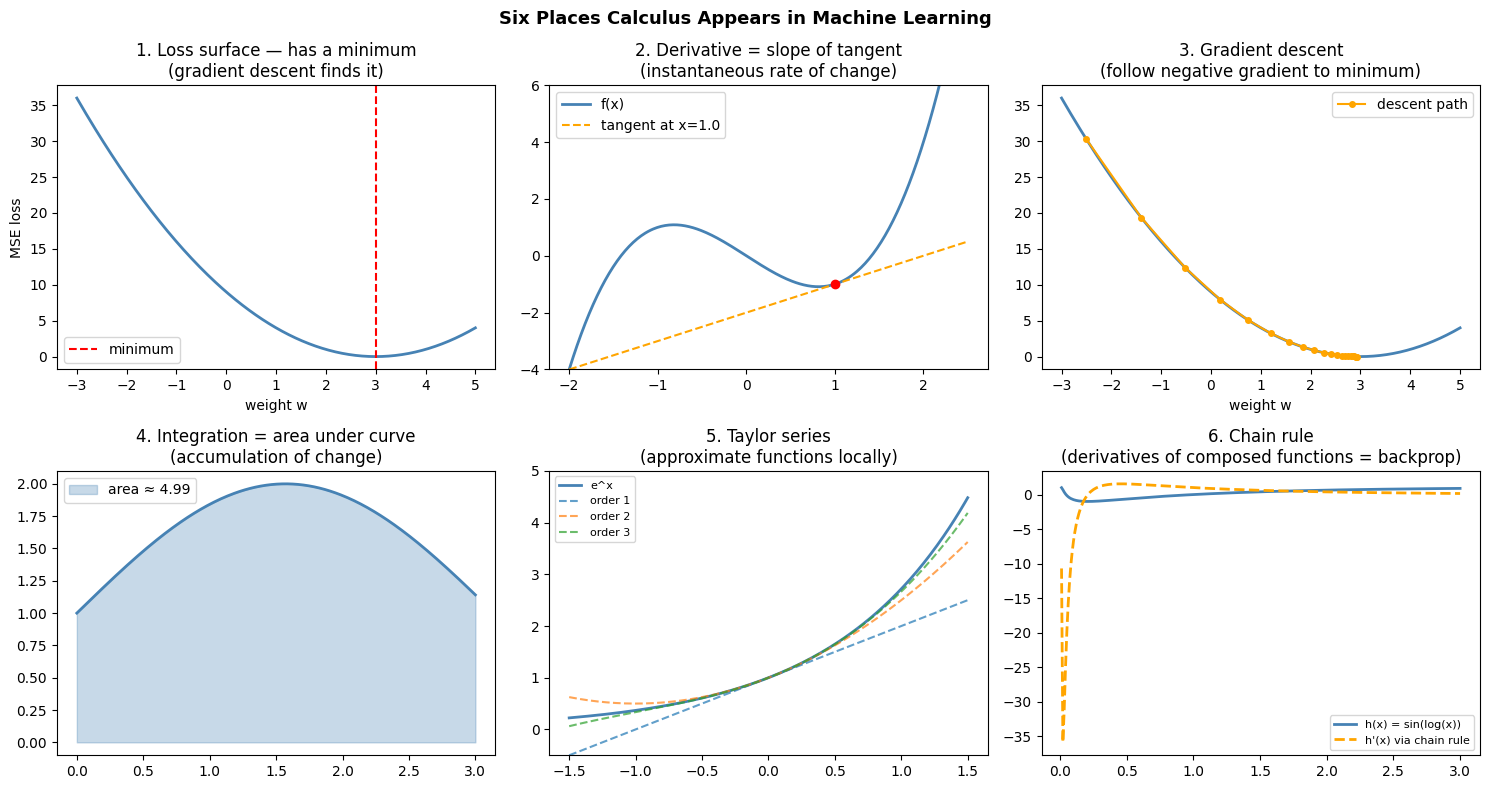

In [3]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# 1. Loss surface of a simple model
w_vals = np.linspace(-3, 5, 300)
# True weight = 3, MSE loss for a 1D linear model with one data point (x=1, y=3)
loss = (w_vals * 1.0 - 3.0) ** 2
axes[0].plot(w_vals, loss, color='steelblue', linewidth=2)
axes[0].axvline(x=3.0, color='red', linestyle='--', label='minimum')
axes[0].set_title('1. Loss surface — has a minimum\n(gradient descent finds it)')
axes[0].set_xlabel('weight w')
axes[0].set_ylabel('MSE loss')
axes[0].legend()

# 2. Derivative = slope of tangent line
x0 = 1.0
f = lambda x: x**3 - 2*x
fp = lambda x: 3*x**2 - 2  # analytical derivative
x_plot = np.linspace(-2, 2.5, 300)
slope = fp(x0)
tangent = f(x0) + slope * (x_plot - x0)
axes[1].plot(x_plot, f(x_plot), color='steelblue', linewidth=2, label='f(x)')
axes[1].plot(x_plot, tangent, color='orange', linewidth=1.5, linestyle='--', label=f"tangent at x={x0}")
axes[1].scatter([x0], [f(x0)], color='red', zorder=5)
axes[1].set_ylim(-4, 6)
axes[1].set_title('2. Derivative = slope of tangent\n(instantaneous rate of change)')
axes[1].legend()

# 3. Gradient descent path
w = -2.5
lr = 0.1
path = [w]
for _ in range(20):
    grad = 2 * (w - 3.0)  # d/dw (w-3)^2
    w = w - lr * grad
    path.append(w)
path = np.array(path)
axes[2].plot(w_vals, loss, color='steelblue', linewidth=2)
axes[2].plot(path, (path - 3.0)**2, 'o-', color='orange', markersize=4, label='descent path')
axes[2].set_title('3. Gradient descent\n(follow negative gradient to minimum)')
axes[2].set_xlabel('weight w')
axes[2].legend()

# 4. Area under curve = integral
x_int = np.linspace(0, 3, 300)
f_int = lambda x: np.sin(x) + 1
axes[3].plot(x_int, f_int(x_int), color='steelblue', linewidth=2)
axes[3].fill_between(x_int, f_int(x_int), alpha=0.3, color='steelblue', label='area ≈ 4.99')
axes[3].set_title('4. Integration = area under curve\n(accumulation of change)')
axes[3].legend()

# 5. Taylor approximation
x_t = np.linspace(-1.5, 1.5, 300)
exact = np.exp(x_t)
t1 = 1 + x_t
t2 = 1 + x_t + x_t**2/2
t3 = 1 + x_t + x_t**2/2 + x_t**3/6
axes[4].plot(x_t, exact, color='steelblue', linewidth=2, label='e^x')
axes[4].plot(x_t, t1, '--', label='order 1', alpha=0.7)
axes[4].plot(x_t, t2, '--', label='order 2', alpha=0.7)
axes[4].plot(x_t, t3, '--', label='order 3', alpha=0.7)
axes[4].set_ylim(-0.5, 5)
axes[4].set_title('5. Taylor series\n(approximate functions locally)')
axes[4].legend(fontsize=8)

# 6. Backprop: chain rule
# Show composite function and its derivative
x_c = np.linspace(0.01, 3, 300)
h = lambda x: np.sin(np.log(x))  # h(x) = sin(log(x))
dh = lambda x: np.cos(np.log(x)) / x  # chain rule: cos(log(x)) * (1/x)
axes[5].plot(x_c, h(x_c), color='steelblue', linewidth=2, label='h(x) = sin(log(x))')
axes[5].plot(x_c, dh(x_c), color='orange', linewidth=2, linestyle='--', label="h'(x) via chain rule")
axes[5].set_title('6. Chain rule\n(derivatives of composed functions = backprop)')
axes[5].legend(fontsize=8)

plt.suptitle('Six Places Calculus Appears in Machine Learning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. The Sequence of Ideas

Calculus has a natural order. Each concept depends on the previous:

```
1. Limits          — what does f(x) approach as x → a?
2. Derivatives     — limit of the difference quotient [f(x+h) - f(x)] / h as h → 0
3. Gradient        — vector of partial derivatives
4. Chain rule      — derivative of composed functions
5. Integration     — antiderivative / area under curve
6. Diff. equations — functions defined by their own derivative
```

This is the order we follow. Each subsequent chapter adds one layer.

## 5. A Concrete Preview: The Derivative as a Limit

In [4]:
# The derivative of f(x) = x^2 at x=2 is 4.
# Let's watch the difference quotient converge to 4 as h shrinks.

f = lambda x: x**2
x0 = 2.0

h_values = [1.0, 0.5, 0.1, 0.01, 0.001, 0.0001, 1e-7, 1e-10, 1e-14]
approx_derivatives = [(f(x0 + h) - f(x0)) / h for h in h_values]

print(f"f(x) = x^2   at x = {x0}")
print(f"Exact derivative f'(2) = 2*2 = 4.0")
print()
print(f"{'h':>12}  {'[f(x+h)-f(x)]/h':>18}  {'error':>12}")
print('-' * 50)
for h, approx in zip(h_values, approx_derivatives):
    print(f"{h:>12.2e}  {approx:>18.10f}  {abs(approx - 4.0):>12.2e}")

print()
print('Note: very small h introduces floating-point error (see ch038 — Precision and Floating Point).')
print('The sweet spot is around h=1e-5 to 1e-7.')

f(x) = x^2   at x = 2.0
Exact derivative f'(2) = 2*2 = 4.0

           h     [f(x+h)-f(x)]/h         error
--------------------------------------------------
    1.00e+00        5.0000000000      1.00e+00
    5.00e-01        4.5000000000      5.00e-01
    1.00e-01        4.1000000000      1.00e-01
    1.00e-02        4.0100000000      1.00e-02
    1.00e-03        4.0010000000      1.00e-03
    1.00e-04        4.0001000000      1.00e-04
    1.00e-07        4.0000000912      9.12e-08
    1.00e-10        4.0000003310      3.31e-07
    1.00e-14        4.0856207306      8.56e-02

Note: very small h introduces floating-point error (see ch038 — Precision and Floating Point).
The sweet spot is around h=1e-5 to 1e-7.


## 6. Why Not Just Use Libraries?

PyTorch and TensorFlow compute gradients automatically. You could use them without understanding calculus at all.

The problem arises when:
- A gradient explodes or vanishes and you don't know why
- You need to implement a custom loss function and verify its gradient is correct
- You want to understand why batch normalization stabilizes training
- You're debugging a network that refuses to learn

At those moments, "the library handles it" is not an answer. The chapters ahead give you the answer.

---

## 7. Summary

| Concept | What It Answers | Where in This Book |
|---------|----------------|--------------------|
| Derivative | How fast is this changing? | ch205–208 |
| Gradient | In which direction does this grow fastest? | ch209–211 |
| Gradient descent | How do we move toward the minimum? | ch212–214 |
| Chain rule | How does a composed function change? | ch215 |
| Backpropagation | How does a neural network learn? | ch216 |
| Integral | How much total change? | ch221–224 |
| Diff. equations | How does a system evolve? | ch225–226 |

---

## 8. Forward References

Every concept in this chapter will be made precise:
- Limits: ch203–204
- Derivatives: ch205–207
- Gradient descent end-to-end: ch228–230
- Integration for probability: these ideas reappear in ch241–270 (Part VIII — Probability), where integrating probability density functions gives cumulative probabilities.